# Tóm Tắt Thuật Toán Naive Bayes Classifier (NBC)

**Naive Bayes Classifier (NBC)** là một thuật toán phân lớp dựa trên định lý Bayes, thường được ứng dụng mạnh mẽ trong các bài toán phân loại văn bản.

## 1. Tư Tưởng Cốt Lõi và Công Thức Bayes
Để xác định một điểm dữ liệu $x$ thuộc về class $c$ nào, thuật toán sẽ tính xác suất $p(c|x)$ và chọn ra class có xác suất cao nhất. Dựa vào định lý Bayes, biểu thức này được biến đổi thành việc đi tìm class $c$ tối đa hóa biểu thức $p(x|c)p(c)$ (vì mẫu số $p(x)$ giống nhau ở mọi class).
- $p(c)$ là xác suất tiên nghiệm (prior), thường được tính bằng tỉ lệ điểm dữ liệu của class $c$ trong tập training.
- $p(x|c)$ là phân phối của các điểm dữ liệu trong class $c$, thường rất khó tính do $x$ là một biến ngẫu nhiên nhiều chiều.

## 2. Giả Thiết "Ngây Thơ" (Naive)
Để giải quyết sự phức tạp của việc tính $p(x|c)$, thuật toán đặt ra một giả thiết "ngây ngô" (naive) cực kỳ chặt chẽ: **các thành phần của điểm dữ liệu $x$ là hoàn toàn độc lập với nhau nếu biết trước class $c$ (conditionally independent given class)**.
Nhờ giả thiết này, xác suất được tính đơn giản bằng tích các xác suất thành phần: $p(x|c) = \prod_{i=1}^d p(x_i|c)$.

Dù trong thực tế, các đặc trưng hiếm khi hoàn toàn độc lập với nhau, nhưng giả thiết phi thực tế này lại mang đến những kết quả tốt một cách bất ngờ.

## 3. Khắc Phục Sai Số Tính Toán (Underflow)
Vì công thức tính là tích của rất nhiều các xác suất (các số nhỏ hơn 1), kết quả có thể tiến tới một số cực nhỏ gây ra sai số tính toán. Để khắc phục, người ta sử dụng hàm $\log$ để chuyển phép nhân thành phép cộng:
$$c = \arg\max_c \left[ \log(p(c)) + \sum_{i=1}^d \log(p(x_i|c)) \right]$$

## 4. Ba Mô Hình Phân Phối Phổ Biến của NBC
Tùy thuộc vào loại dữ liệu mà cách tính $p(x_i|c)$ sẽ khác nhau:
- **Gaussian Naive Bayes:** Dùng khi các thành phần của dữ liệu là các **biến liên tục**. Thuật toán giả sử mỗi chiều dữ liệu tuân theo một phân phối chuẩn (Gaussian distribution) với kỳ vọng và phương sai riêng.
- **Multinomial Naive Bayes:** Chủ yếu dùng trong phân loại văn bản, khi đặc trưng (features) là số lượng đếm (ví dụ: tần suất xuất hiện của từ/Bags of Words). Mô hình này luôn đi kèm với kỹ thuật **Laplace smoothing** để tránh trường hợp xác suất bằng 0 khi gặp một từ mới trong tập test chưa từng xuất hiện ở tập training.
- **Bernoulli Naive Bayes:** Áp dụng cho các biến đặc trưng dạng **nhị phân (binary)**, chỉ mang giá trị 0 hoặc 1 (ví dụ: từ có xuất hiện trong văn bản hay không, không quan tâm số lần).

## 5. Ưu Điểm Nổi Bật của Naive Bayes
- **Tốc độ cực nhanh:** Việc giả sử các thành phần độc lập giúp quá trình training và test diễn ra với tốc độ cực kỳ nhanh so với nhiều phương pháp phức tạp khác, rất phù hợp với dữ liệu lớn (large-scale).
- **Hoạt động tốt với ít dữ liệu:** Nếu giả thiết về tính độc lập được thỏa mãn, thuật toán được cho là mang lại kết quả tốt hơn SVM hay Logistic Regression khi có ít dữ liệu training.

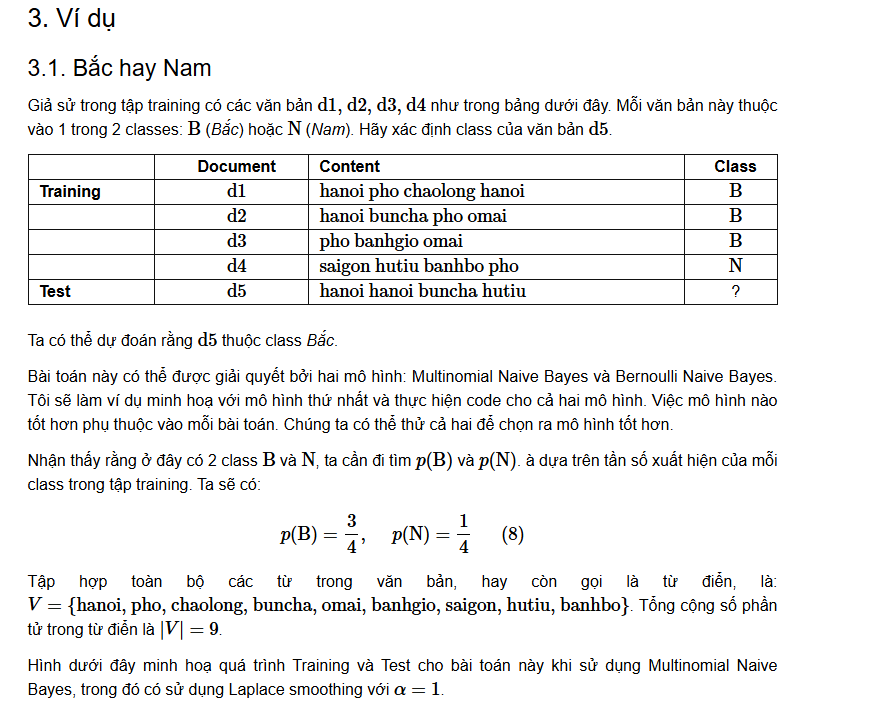

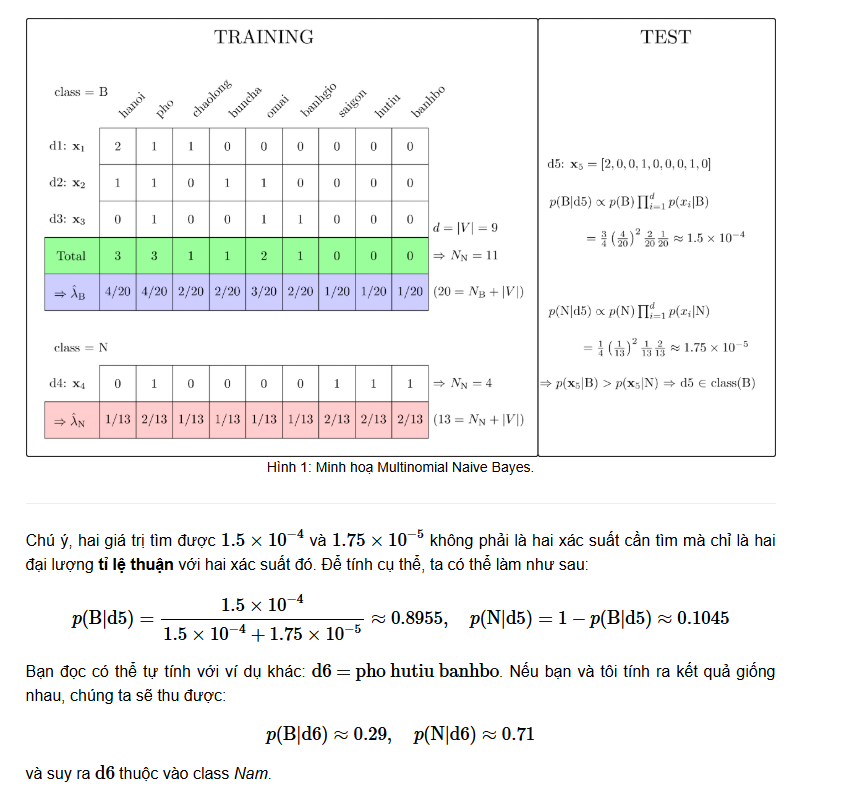

In [3]:
from __future__ import print_function
from sklearn.naive_bayes import MultinomialNB
import numpy as np 

# train data
d1 = [2, 1, 1, 0, 0, 0, 0, 0, 0]
d2 = [1, 1, 0, 1, 1, 0, 0, 0, 0]
d3 = [0, 1, 0, 0, 1, 1, 0, 0, 0]
d4 = [0, 1, 0, 0, 0, 0, 1, 1, 1]

train_data = np.array([d1, d2, d3, d4])
label = np.array(['B', 'B', 'B', 'N']) 

# test data
d5 = np.array([[2, 0, 0, 1, 0, 0, 0, 1, 0]])
d6 = np.array([[0, 1, 0, 0, 0, 0, 0, 1, 1]])

## call MultinomialNB
clf = MultinomialNB()
# training 
clf.fit(train_data, label)

# test
print('Predicting class of d5:', str(clf.predict(d5)[0]))
print('Probability of d6 in each class:', clf.predict_proba(d6))

Predicting class of d5: B
Probability of d6 in each class: [[0.29175335 0.70824665]]
